In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings 
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [3]:
df = pd.read_csv(r"D:\AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [7]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df.shape[0]

6362620

In [11]:
fraud_percentage = (df["isFraud"].value_counts()[1] / df.shape[0]) * 100
print("Fraud Percentage:", fraud_percentage)

Fraud Percentage: 0.12908204481801522


In [12]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [13]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


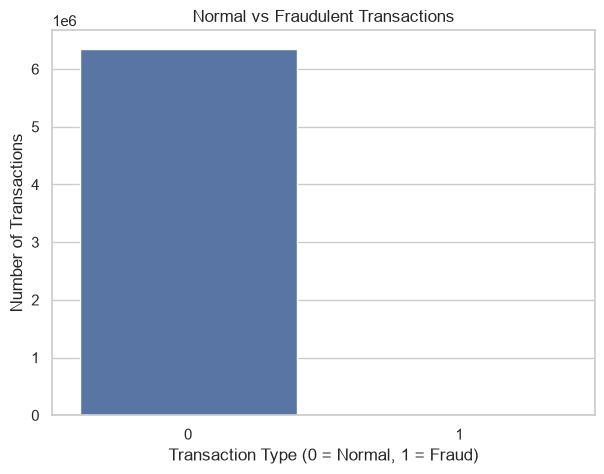

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='isFraud')

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Transaction Type (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [15]:
fraud_by_type = pd.crosstab(df['type'], df['isFraud'])

print(fraud_by_type)

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


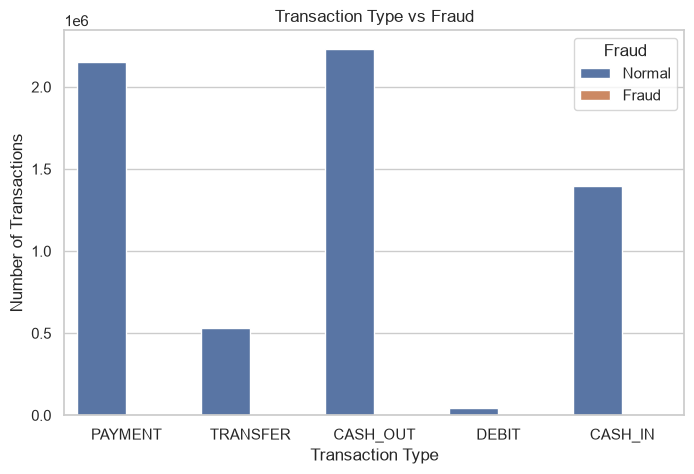

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='type', hue='isFraud')

plt.title("Transaction Type vs Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.legend(title="Fraud", labels=["Normal", "Fraud"])

plt.show()

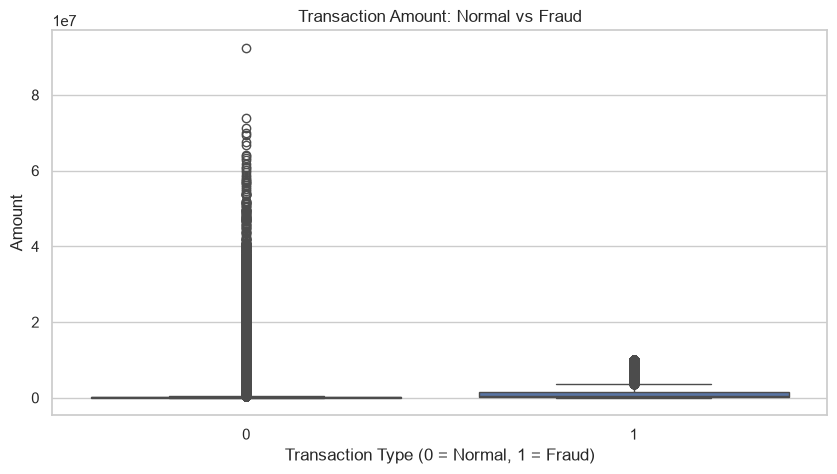

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='isFraud', y='amount')

plt.title("Transaction Amount: Normal vs Fraud")
plt.xlabel("Transaction Type (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

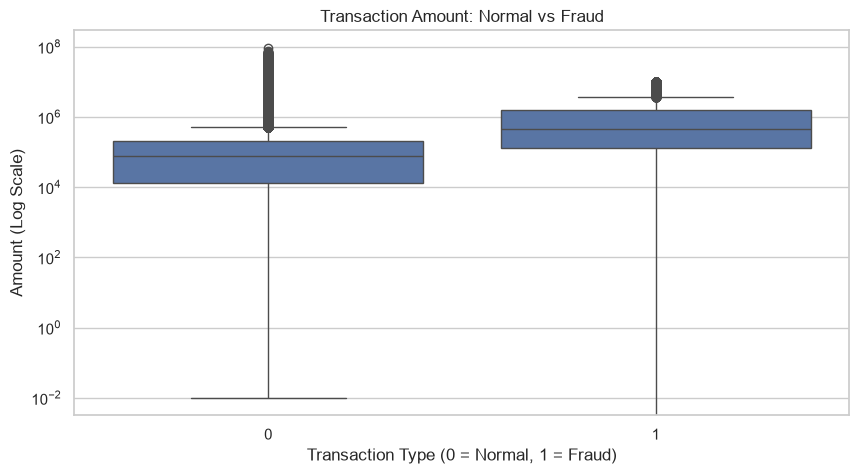

In [18]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='isFraud', y='amount')

plt.yscale('log')

plt.title("Transaction Amount: Normal vs Fraud")
plt.xlabel("Transaction Type (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount (Log Scale)")

plt.show()

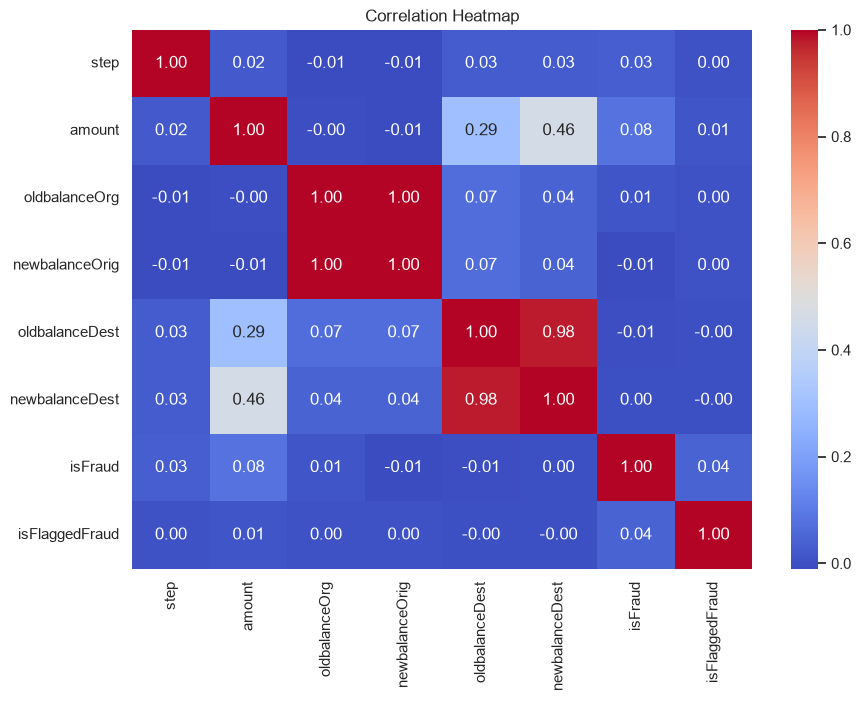

In [19]:
plt.figure(figsize=(10,7))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

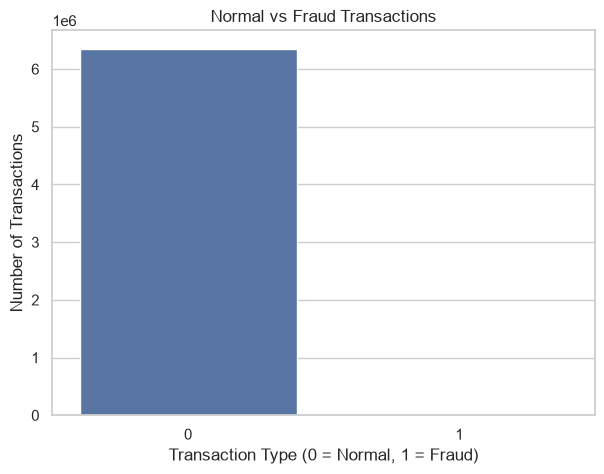

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='isFraud')

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Type (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

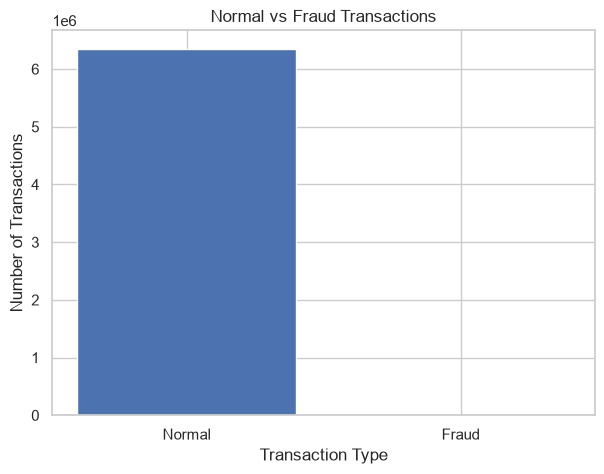

In [21]:
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(['Normal', 'Fraud'], 
        [fraud_counts[0], fraud_counts[1]])

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

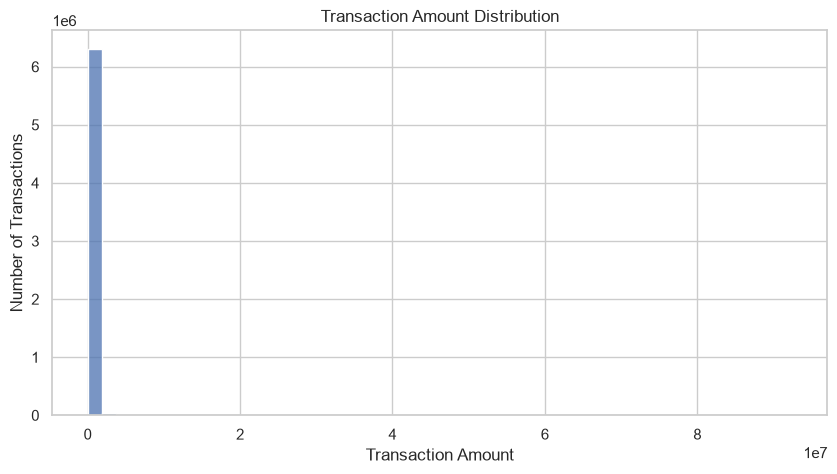

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='amount', bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

In [23]:
X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6362620, 9)
Target shape: (6362620,)


In [24]:
X = X.drop(columns=['nameOrig', 'nameDest'])

X = pd.get_dummies(X, columns=['type'], drop_first=True)

print("New Features shape:", X.shape)
X.head()

New Features shape: (6362620, 10)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,False,False,True,False


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5090096, 10)
X_test: (1272524, 10)
y_train: (5090096,)
y_test: (1272524,)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear'
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.94      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.95      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524



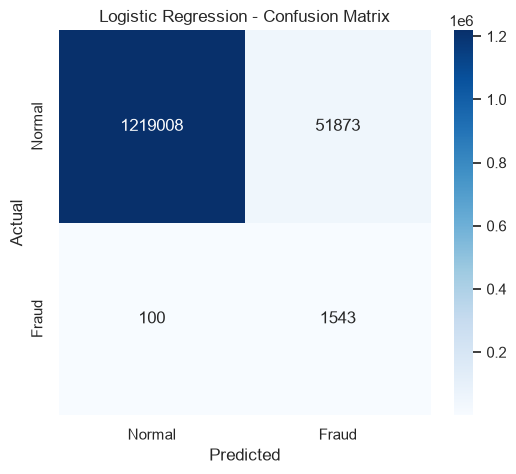

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

# Fraud probability
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression ROC-AUC:", roc_auc)

Logistic Regression ROC-AUC: 0.9888641748662049


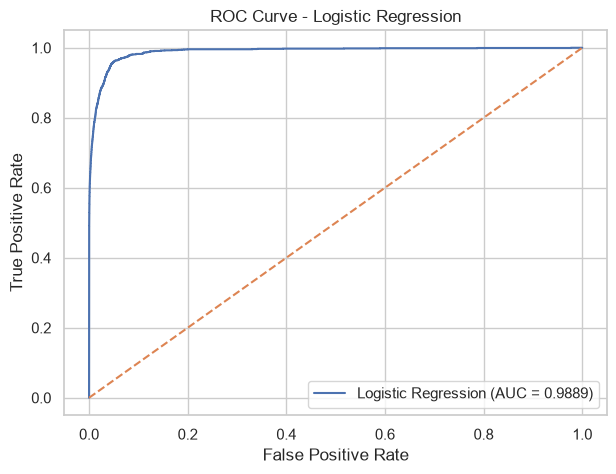

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

Average Precision Score: 0.5713421809458707


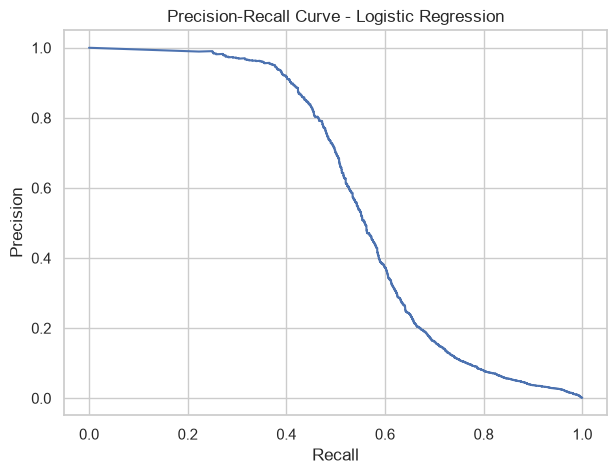

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test, y_prob_log
)

average_precision = average_precision_score(y_test, y_prob_log)

print("Average Precision Score:", average_precision)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.14      0.99      0.25      1643

    accuracy                           0.99   1272524
   macro avg       0.57      0.99      0.62   1272524
weighted avg       1.00      0.99      1.00   1272524



In [32]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)

Decision Tree ROC-AUC: 0.9924722788390783


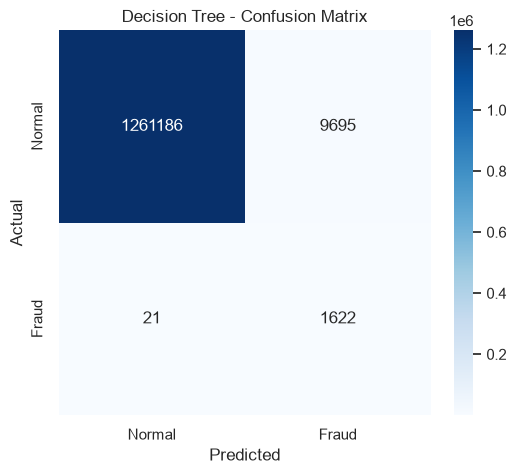

In [33]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.11      0.99      0.19      1643

    accuracy                           0.99   1272524
   macro avg       0.55      0.99      0.59   1272524
weighted avg       1.00      0.99      0.99   1272524



In [35]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.9992882396619347


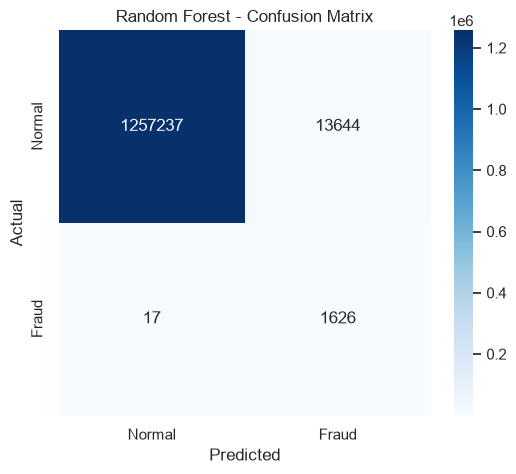

In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf
    ]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.028886,0.939136,0.056049,0.988864
1,Decision Tree,0.143324,0.987219,0.250309,0.992472
2,Random Forest,0.106483,0.989653,0.192278,0.999288


In [38]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

          Feature  Importance
2   oldbalanceOrg    0.293627
3  newbalanceOrig    0.173332
1          amount    0.165194
9   type_TRANSFER    0.097861
0            step    0.063458
5  newbalanceDest    0.060276
8    type_PAYMENT    0.054722
6   type_CASH_OUT    0.050966
4  oldbalanceDest    0.040359
7      type_DEBIT    0.000206


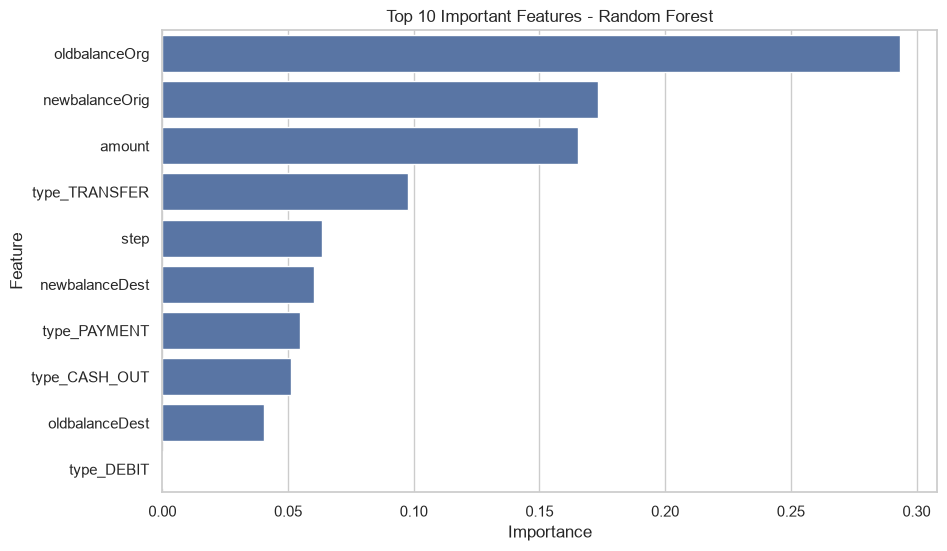

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [40]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test, y_prob_rf
)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_index = f1_scores.argmax()
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best Precision:", precision[best_index])
print("Best Recall:", recall[best_index])
print("Best F1-Score:", f1_scores[best_index])

Best Threshold: 0.9279254380998294
Best Precision: 0.9327789327789328
Best Recall: 0.8192331101643335
Best F1-Score: 0.8723266363727634


In [41]:
y_pred_rf_tuned = (y_prob_rf >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

Confusion Matrix:
[[1270784      97]
 [    297    1346]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.93      0.82      0.87      1643

    accuracy                           1.00   1272524
   macro avg       0.97      0.91      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524



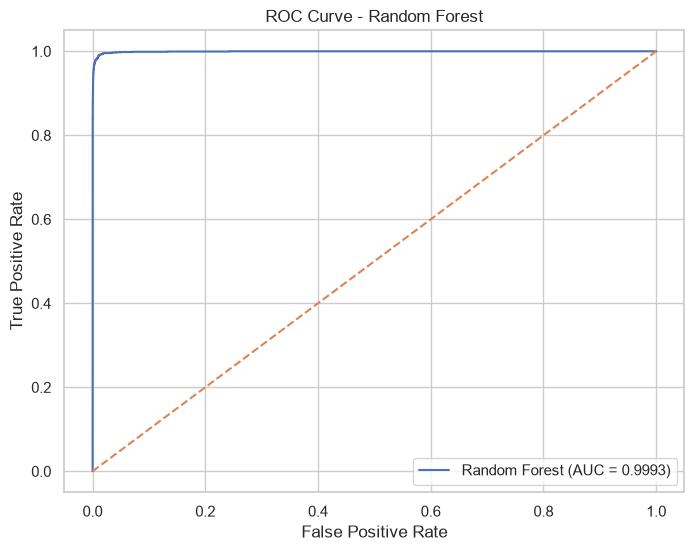

In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc_final = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_final:.4f})')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [43]:
# Final Model Evaluation - Random Forest

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_rf_tuned)
precision = precision_score(y_test, y_pred_rf_tuned)
recall = recall_score(y_test, y_pred_rf_tuned)
f1 = f1_score(y_test, y_pred_rf_tuned)

print("Final Random Forest Model Performance")
print("--------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Final Random Forest Model Performance
--------------------------------------
Accuracy  : 0.9997
Precision : 0.9328
Recall    : 0.8192
F1-Score  : 0.8723


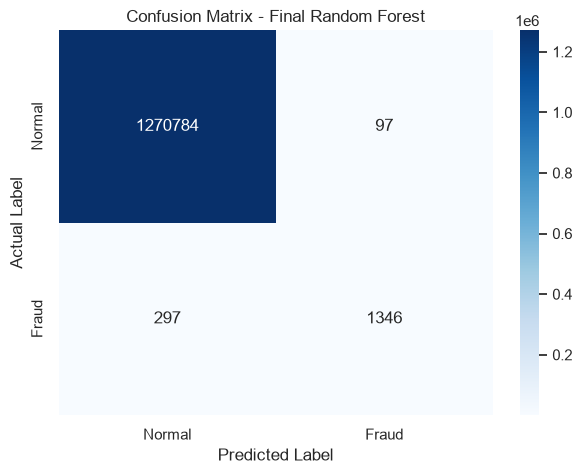

In [44]:
# Confusion Matrix Heatmap - Final Random Forest

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix - Final Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [45]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# Final Project Summary

print("FINAL MODEL SUMMARY")
print("=" * 40)

print("Best Model: Random Forest")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {0.9989503527:.4f}")

print("\nConclusion:")
print("Random Forest performed best among the evaluated models.")
print("Threshold tuning improved the balance between precision and recall.")
print("The model can effectively distinguish between normal and fraudulent transactions.")

FINAL MODEL SUMMARY
Best Model: Random Forest
Accuracy  : 0.9997
Precision : 0.9328
Recall    : 0.8192
F1-Score  : 0.8723
ROC-AUC   : 0.9990

Conclusion:
Random Forest performed best among the evaluated models.
Threshold tuning improved the balance between precision and recall.
The model can effectively distinguish between normal and fraudulent transactions.


Feature Importance:
oldbalanceOrg     0.293627
newbalanceOrig    0.173332
amount            0.165194
type_TRANSFER     0.097861
step              0.063458
newbalanceDest    0.060276
type_PAYMENT      0.054722
type_CASH_OUT     0.050966
oldbalanceDest    0.040359
type_DEBIT        0.000206
dtype: float64


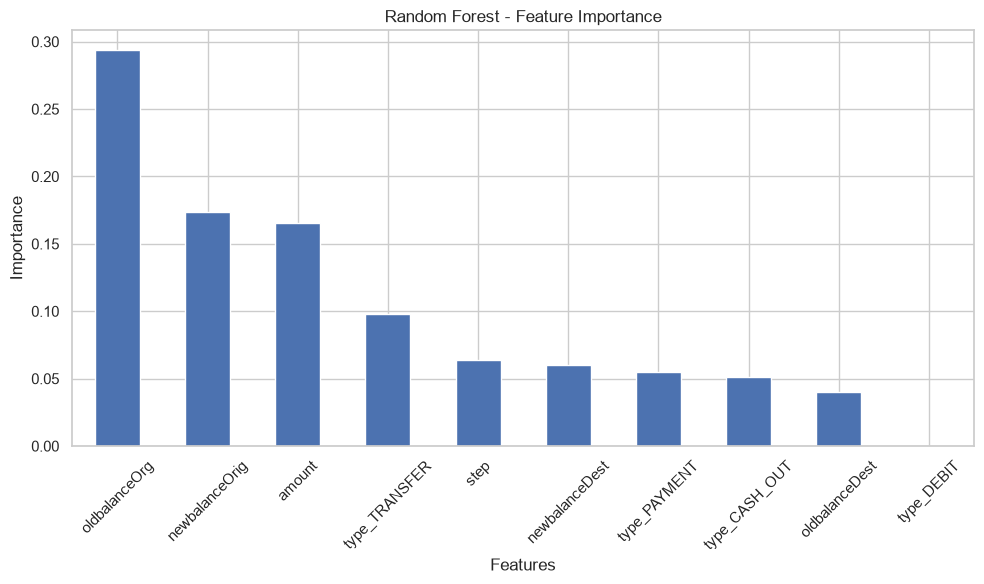

In [47]:
# Random Forest Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title("Random Forest - Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

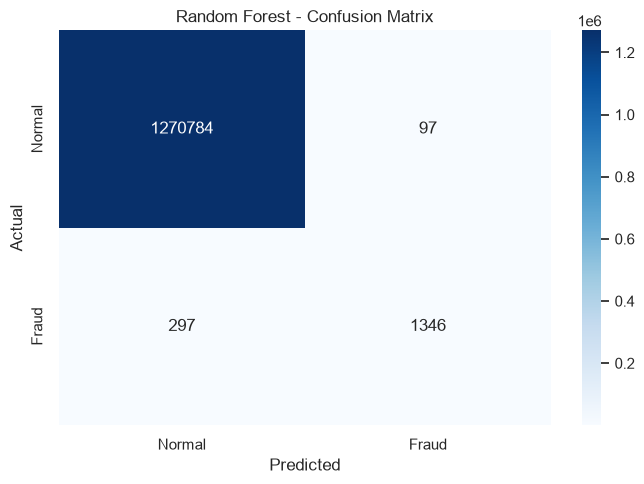

In [48]:
# Confusion Matrix Heatmap

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [49]:
# Sample Fraud Prediction Demo

import pandas as pd

sample = X_test.iloc[:10].copy()

sample_prediction = rf_model.predict(sample)

result = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": sample_prediction
})

result["Actual"] = result["Actual"].map({0: "Normal", 1: "Fraud"})
result["Predicted"] = result["Predicted"].map({0: "Normal", 1: "Fraud"})

print("Sample Transaction Predictions:")
display(result)

Sample Transaction Predictions:


,Actual,Predicted
0,Normal,Normal
1,Normal,Normal
2,Normal,Normal
3,Normal,Normal
4,Normal,Normal
5,Normal,Normal
6,Normal,Normal
7,Normal,Normal
8,Normal,Normal
9,Normal,Normal


In [50]:
# Save Final Random Forest Model

import joblib

joblib.dump(rf_model, "fraud_detection_random_forest.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [51]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
